# Project 2: GDP per capita and CO2 emissions per capita


In this project, I explore the relationship between **GDP per capita** and **per capita CO2 emissions** for one country over time.

- GDP per capita (current US$) comes from the World Bank World Development Indicators, indicator `NY.GDP.PCAP.CD`.  
  - Source: https://data.worldbank.org/indicator/NY.GDP.PCAP.CD
- CO2 emissions excluding LULUCF per capita (t CO2e/capita) comes from the World Bank indicator `EN.GHG.CO2.PC.CE.AR5`.  
  - Source: https://data.worldbank.org/indicator/EN.GHG.CO2.PC.CE.AR5

I had originally planned to use an older CO2 per capita indicator (`EN.ATM.CO2E.PC`), but it is no longer available on the World Bank site.  
This forced me to adjust my plan and switch to the newer greenhouse gas series, which still measures **per capita CO2 emissions** but excludes land-use and forestry (LULUCF).

To make the CSV files easier to read with pandas, I used Excel once to:
- remove the metadata rows at the top of each downloaded CSV, and  
- save a cleaned version where the first row contains the column names  
  (`Country Name`, `Country Code`, `Indicator Name`, `Indicator Code`, `1960`, `1961`, ...).

**Research question**

> As GDP per capita rises in the United States, do per capita CO2 emissions (excluding land-use and forestry) also increase, or do they start to decouple?

I have not worked with this CO2 dataset before, so part of the goal is simply to get comfortable cleaning and combining these World Bank time series in code.

## 1. Setup and loading the data

I use Python, pandas, and matplotlib for this analysis.  
I also define a `country_name` variable so that I can easily switch to another country later without changing the rest of the code.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

country_name = "United States"

gdp_raw = pd.read_csv("data/gdp_per_capita_worldbank.csv")
co2_raw = pd.read_csv("data/co2_per_capita_excl_lulucf_worldbank.csv")

gdp_raw.head()
co2_raw.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,4.281504,4.459794,4.291167,4.277923,5.108834,4.168086,4.648097,4.684559,4.936708,NaN
1,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,1.043373,1.026116,1.012873,0.997157,0.983492,0.845417,0.863533,0.816361,0.784641,NaN
2,Afghanistan,AFG,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.246706,0.216930,0.226011,0.215878,0.191491,0.180555,0.198268,0.203552,0.210043,NaN
3,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.499587,0.506323,0.495060,0.509713,0.518890,0.497159,0.512749,0.505462,0.482217,NaN
4,Angola,AGO,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,1.175429,1.072053,0.924169,0.839019,0.851665,0.619139,0.731567,0.767587,0.768163,NaN


## 2. Reshape the data: from wide format to long format

The World Bank CSV files store each year as a separate column (1960, 1961, ...).  
For time series analysis, it is easier to work with a long format where we have:

- one column for the year, and  
- one column for the value of the indicator.

Here I use `pd.melt()` to reshape both GDP per capita and CO2 emissions data into long format.


In [23]:
# Columns that should stay as identifiers (not melted)
id_columns = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]

# Reshape GDP per capita data: wide -> long
gdp_long = gdp_raw.melt(
    id_vars=id_columns, var_name="year", value_name="gdp_per_capita"
)

# Reshape CO2 per capita data: wide -> long
co2_long = co2_raw.melt(
    id_vars=id_columns, var_name="year", value_name="co2_per_capita"
)

gdp_long.head()


,Country Name,Country Code,Indicator Name,Indicator Code,year,gdp_per_capita
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,186.121835
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,121.939925
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN


In [24]:
co2_long.head()


,Country Name,Country Code,Indicator Name,Indicator Code,year,co2_per_capita
0,Aruba,ABW,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1960,NaN
1,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1960,NaN
2,Afghanistan,AFG,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1960,NaN
3,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1960,NaN
4,Angola,AGO,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1960,NaN


## 3. Clean the long-format data

After melting, the `year` column is stored as a string.  
I keep only rows where `year` looks like a 4-digit year, and then:

- convert `year` to an integer,  
- convert the indicator values to numeric types,  
- drop rows with missing values.

This makes it easier to plot and merge the two datasets.


In [25]:
# Keep only rows where "year" looks like a 4-digit number
gdp_long = gdp_long[gdp_long["year"].str.fullmatch(r"\d{4}")]
co2_long = co2_long[co2_long["year"].str.fullmatch(r"\d{4}")]

# Convert year to integer
gdp_long["year"] = gdp_long["year"].astype(int)
co2_long["year"] = co2_long["year"].astype(int)

# Convert values to numeric (coerce errors to NaN)
gdp_long["gdp_per_capita"] = pd.to_numeric(gdp_long["gdp_per_capita"], errors="coerce")
co2_long["co2_per_capita"] = pd.to_numeric(co2_long["co2_per_capita"], errors="coerce")

# Drop rows with missing values in the indicator columns
gdp_long = gdp_long.dropna(subset=["gdp_per_capita"])
co2_long = co2_long.dropna(subset=["co2_per_capita"])

gdp_long.head()


,Country Name,Country Code,Indicator Name,Indicator Code,year,gdp_per_capita
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,186.121835
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,121.939925
9,Argentina,ARG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,778.251707
13,Australia,AUS,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,1810.706430
14,Austria,AUT,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,939.914815


In [26]:
co2_long.head()


,Country Name,Country Code,Indicator Name,Indicator Code,year,co2_per_capita
2660,Aruba,ABW,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1970,0.427481
2661,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1970,1.355303
2662,Afghanistan,AFG,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1970,0.153577
2663,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1970,0.347427
2664,Angola,AGO,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1970,1.526435


## 4. Focus on one country

For this project, I focus on a single country.  
Here I choose the value stored in the `country_name` variable (by default, `"United States"`).

I filter the long tables so that they only contain data for this country.

In [27]:
# Filter GDP data for the selected country
gdp_country = gdp_long[gdp_long["Country Name"] == country_name].copy()

# Filter CO2 data for the selected country
co2_country = co2_long[co2_long["Country Name"] == country_name].copy()

gdp_country.head()


,Country Name,Country Code,Indicator Name,Indicator Code,year,gdp_per_capita
251,United States,USA,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,3002.089295
517,United States,USA,GDP per capita (current US$),NY.GDP.PCAP.CD,1961,3062.974116
783,United States,USA,GDP per capita (current US$),NY.GDP.PCAP.CD,1962,3241.857659
1049,United States,USA,GDP per capita (current US$),NY.GDP.PCAP.CD,1963,3373.357305
1315,United States,USA,GDP per capita (current US$),NY.GDP.PCAP.CD,1964,3573.063546


In [28]:
(
    gdp_country["year"].min(),
    gdp_country["year"].max(),
    co2_country["year"].min(),
    co2_country["year"].max(),
)


(np.int64(1960), np.int64(2024), np.int64(1970), np.int64(2023))

## 5. Merge GDP per capita and CO2 emissions per capita

To compare the two indicators directly, I merge the country-level GDP per capita  
and CO2 emissions per capita tables on the `year` column.

Each row in the merged table will represent one year with:

- GDP per capita (current US dollars), and  
- CO2 emissions per capita (t CO2e per person, excluding LULUCF).


In [29]:
# Keep only the columns we actually need
gdp_country_small = gdp_country[["year", "gdp_per_capita"]]
co2_country_small = co2_country[["year", "co2_per_capita"]]

# Merge on year, keeping only years that appear in both datasets
merged = pd.merge(gdp_country_small, co2_country_small, on="year", how="inner")

# Sort by year
merged = merged.sort_values("year").reset_index(drop=True)

merged.head()


,year,gdp_per_capita,co2_per_capita
0,1970,5234.296666,22.409257
1,1971,5609.382600,21.476922
2,1972,6094.017990,22.443387
3,1973,6726.358956,23.108247
4,1974,7225.691360,22.107051


In [30]:
merged.info()
merged.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            54 non-null     int64  
 1   gdp_per_capita  54 non-null     float64
 2   co2_per_capita  54 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.4 KB


year              0
gdp_per_capita    0
co2_per_capita    0
dtype: int64

## 6. Exploratory visualizations

Before building the final chart, I look at each series separately to get a sense of  
their trends over time.


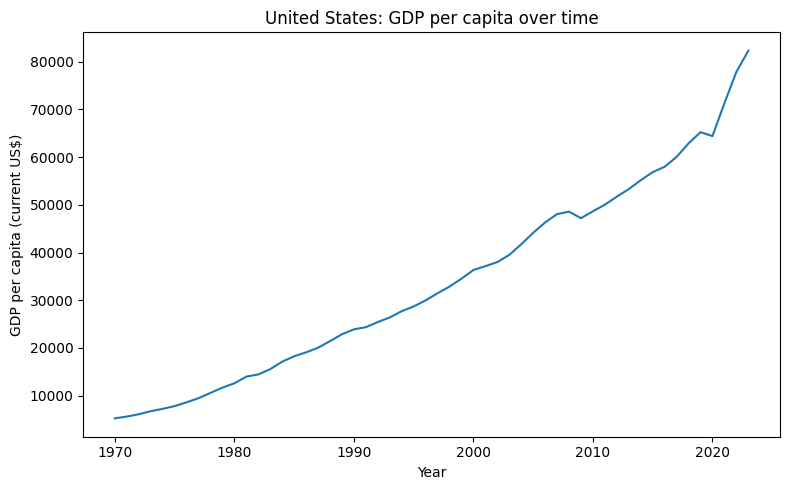

In [31]:
plt.plot(merged["year"], merged["gdp_per_capita"])
plt.title(f"{country_name}: GDP per capita over time")
plt.xlabel("Year")
plt.ylabel("GDP per capita (current US$)")
plt.tight_layout()
plt.show()


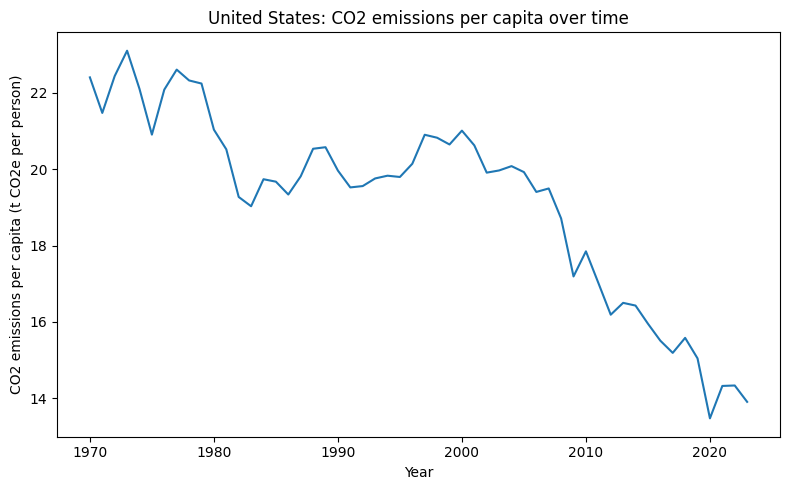

In [32]:
plt.plot(merged["year"], merged["co2_per_capita"])
plt.title(f"{country_name}: CO2 emissions per capita over time")
plt.xlabel("Year")
plt.ylabel("CO2 emissions per capita (t CO2e per person)")
plt.tight_layout()
plt.show()


### First attempt: simple scatter plot

As a first attempt, I try a raw scatter plot of GDP per capita vs CO2 emissions per capita.

This is a quick way to see if there is a simple relationship between the two variables.  
However, because the data spans many decades and the scale of GDP per capita grows dramatically while CO2 per capita stays within a narrower band,  
this plot does not fully show **how the relationship changes over time**.  

That is why I build a second visualization that keeps the time dimension and uses index values for both series.

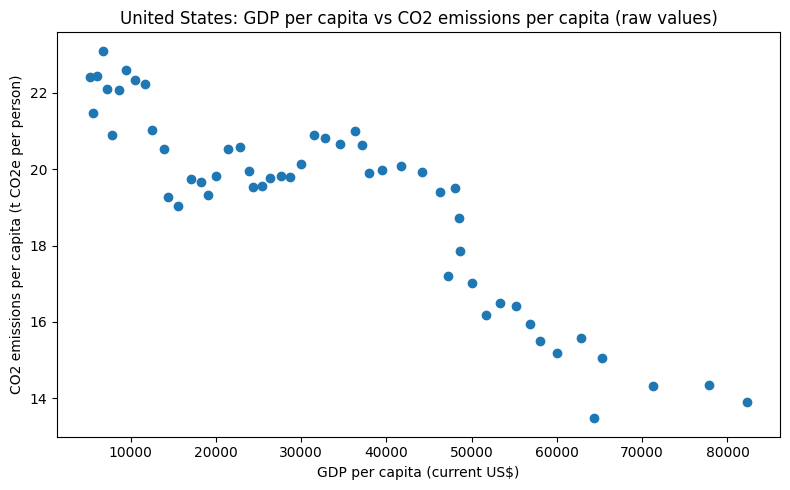

In [33]:
plt.scatter(merged["gdp_per_capita"], merged["co2_per_capita"])
plt.title(f"{country_name}: GDP per capita vs CO2 emissions per capita (raw values)")
plt.xlabel("GDP per capita (current US$)")
plt.ylabel("CO2 emissions per capita (t CO2e per person)")
plt.tight_layout()
plt.show()


## 7. Main visualization: GDP per capita and CO2 emissions per capita in one chart

To make the two series comparable on the same chart, I create index values:

- For each indicator, I divide by its value in the first year of the sample and multiply by 100.
- This means that the first year is set to 100 for both series.

The index is unitless, but it shows how much each series has grown or declined  
relative to its starting point. This makes it easier to see whether CO2 emissions  
per capita grow in line with GDP per capita, or whether they start to decouple.


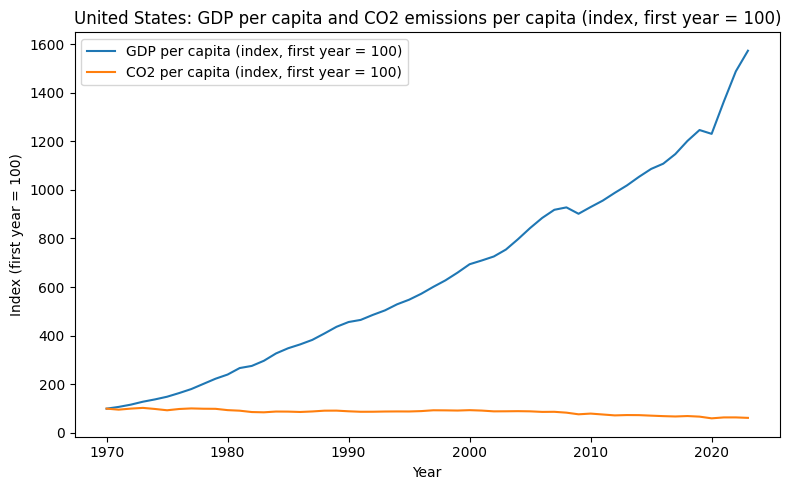

In [34]:
# Create index series (first year = 100)
base_gdp = merged["gdp_per_capita"].iloc[0]
base_co2 = merged["co2_per_capita"].iloc[0]

merged["gdp_index"] = merged["gdp_per_capita"] / base_gdp * 100
merged["co2_index"] = merged["co2_per_capita"] / base_co2 * 100

plt.plot(
    merged["year"],
    merged["gdp_index"],
    label="GDP per capita (index, first year = 100)",
)
plt.plot(
    merged["year"],
    merged["co2_index"],
    label="CO2 per capita (index, first year = 100)",
)

plt.title(
    f"{country_name}: GDP per capita and CO2 emissions per capita (index, first year = 100)"
)
plt.xlabel("Year")
plt.ylabel("Index (first year = 100)")
plt.legend()
plt.tight_layout()
plt.show()


### Alternative view: rescaling the CO2 index for visibility

In the main indexed chart, GDP per capita grows so much that the CO2 index line  
looks almost flat near the bottom of the figure.

To make the movement in CO2 per capita easier to see, I rescale the CO2 index by a constant factor.  
This does **not** change the underlying pattern, but it pulls the orange line away from the x-axis so that small changes are more visible.

The legend and y-axis label make clear that the CO2 index has been rescaled.


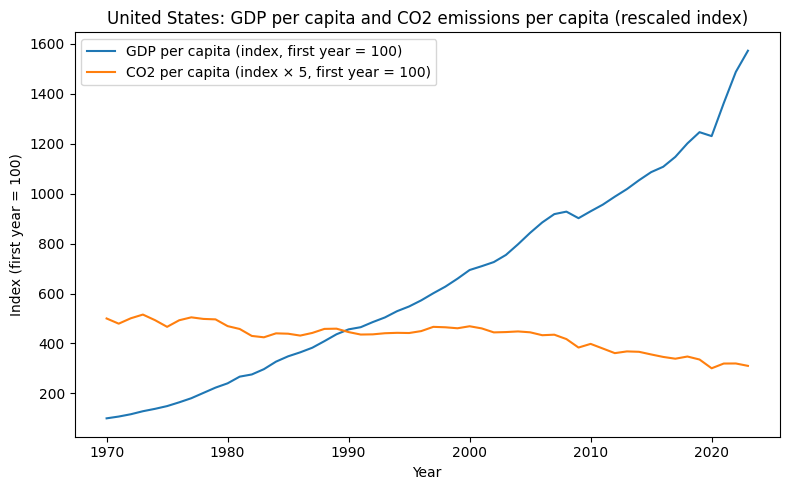

In [35]:
# Rescale the CO2 index by a constant factor for visualization
scale_factor = 5
merged["co2_index_scaled"] = merged["co2_index"] * scale_factor

plt.plot(
    merged["year"],
    merged["gdp_index"],
    label="GDP per capita (index, first year = 100)",
)
plt.plot(
    merged["year"],
    merged["co2_index_scaled"],
    label=f"CO2 per capita (index × {scale_factor}, first year = 100)",
)

plt.title(
    f"{country_name}: GDP per capita and CO2 emissions per capita (rescaled index)"
)
plt.xlabel("Year")
plt.ylabel("Index (first year = 100)")
plt.legend()
plt.tight_layout()
plt.show()


### Alternative view: two y-axes with actual units

Another way to show both series on one chart is to keep their original units  
and use two y-axes:

- the left y-axis for GDP per capita (in current US dollars), and  
- the right y-axis for CO2 emissions per capita (in t CO2e per person).

This avoids rescaling one series purely for visualization, at the cost of a slightly more complex plot.


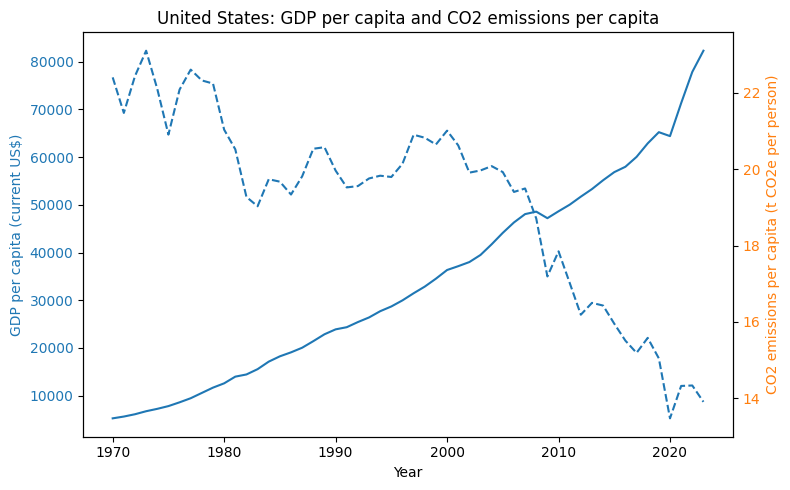

In [36]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Left y-axis: GDP per capita
ax1.plot(
    merged["year"],
    merged["gdp_per_capita"],
    label="GDP per capita",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("GDP per capita (current US$)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: CO2 per capita
ax2 = ax1.twinx()
ax2.plot(
    merged["year"],
    merged["co2_per_capita"],
    label="CO2 per capita",
    linestyle="--",
)
ax2.set_ylabel("CO2 emissions per capita (t CO2e per person)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title(f"{country_name}: GDP per capita and CO2 emissions per capita")
fig.tight_layout()
plt.show()


## 8. Takeaways

From the indexed chart, I see that:

- **GDP per capita** in the United States rises very strongly over the sample period.  
  Relative to the first year in the dataset, the index reaches more than 10–15 times its starting level.
- **CO2 emissions per capita**, by contrast, move within a much narrower range.  
  They increase slightly in earlier decades, but in more recent years they are roughly flat or even somewhat lower than the starting level.

In other words, there is a strong positive relationship between economic activity and emissions in the early part of the sample,  
but in recent decades there are signs of partial decoupling:  
GDP per capita keeps growing, while per-person CO2 emissions no longer grow at the same pace.

### Caveats and limitations

- This is a purely descriptive analysis. I do not control for other factors such as energy mix, environmental policies, or technological improvements.
- The CO2 series excludes land-use and forestry (LULUCF), so it does not capture all possible sources and sinks of emissions.
- Correlation does not imply causation. Even if GDP per capita and CO2 emissions per capita move together for part of the sample,  
  this does not mean that one directly causes the other.
